In [73]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

np.random.seed(42)
random.seed(42)


In [74]:
data_dir = "/content/dataset/animal_dataset"

CATEGORIES = []
for c in os.listdir(data_dir):
    CATEGORIES.append(c)

print("\nClasses:", CATEGORIES)
print("Total number of classes:", len(CATEGORIES))



Classes: ['panda', 'dog', 'cat']
Total number of classes: 3


In [75]:
counts = {}
for c in CATEGORIES:
    folder = os.path.join(data_dir, c)
    files = [f for f in os.listdir(folder)]
    counts[c] = len(files)

print("\nImage counts per class:")
for class_name, count in counts.items():
    print(f"   {class_name}: {count} images")

total_images = sum(counts.values())
print(f"\nTotal images: {total_images}")



Image counts per class:
   panda: 100 images
   dog: 100 images
   cat: 100 images

Total images: 300


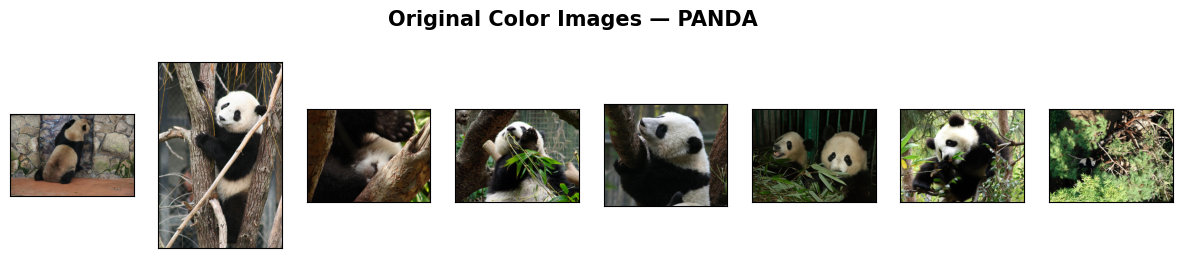

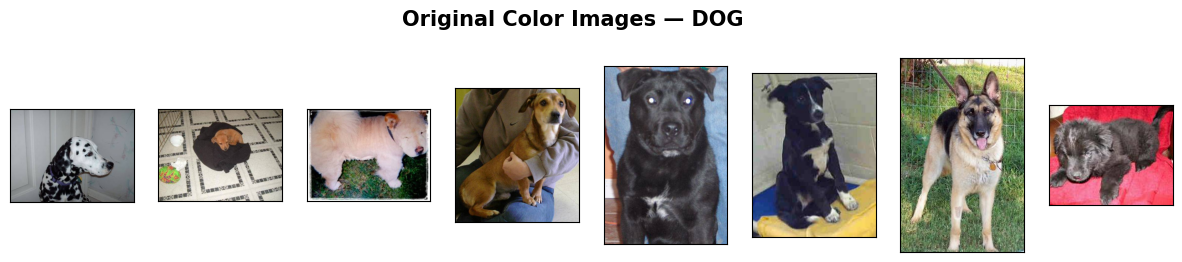

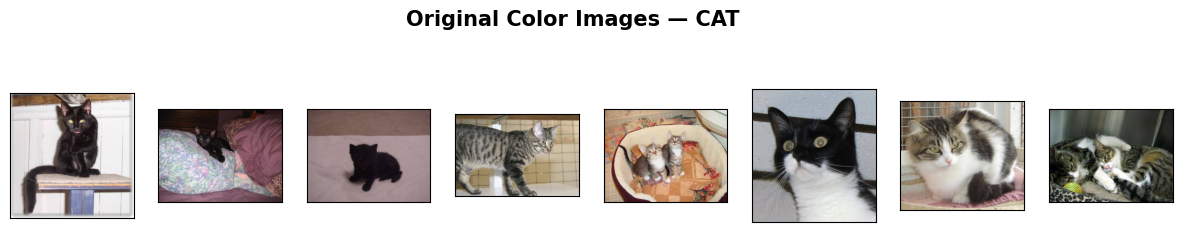

In [76]:
for category in CATEGORIES:
    folder = os.path.join(data_dir, category)
    image_files = os.listdir(folder)[:8]

    fig, axes = plt.subplots(1, 8, figsize=(15, 3))
    fig.suptitle(f"Original Color Images — {category.upper()}", fontsize=15, fontweight='bold')

    for ax, img_file in zip(axes, image_files):
        img_path = os.path.join(folder, img_file)
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()


In [77]:
IMG_SIZE = 32
TRAIN_DATA = []

for category in CATEGORIES:
    path = os.path.join(data_dir, category)
    class_num = CATEGORIES.index(category)
    class_count = 0

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        TRAIN_DATA.append([img_gray, class_num])
        class_count += 1

    print(f" {category}: Loaded {class_count} images")

print(f"\n Total images loaded: {len(TRAIN_DATA)}")
print(f"   Image size: {IMG_SIZE} x {IMG_SIZE} pixels (grayscale)")


 panda: Loaded 100 images
 dog: Loaded 100 images
 cat: Loaded 100 images

 Total images loaded: 300
   Image size: 32 x 32 pixels (grayscale)


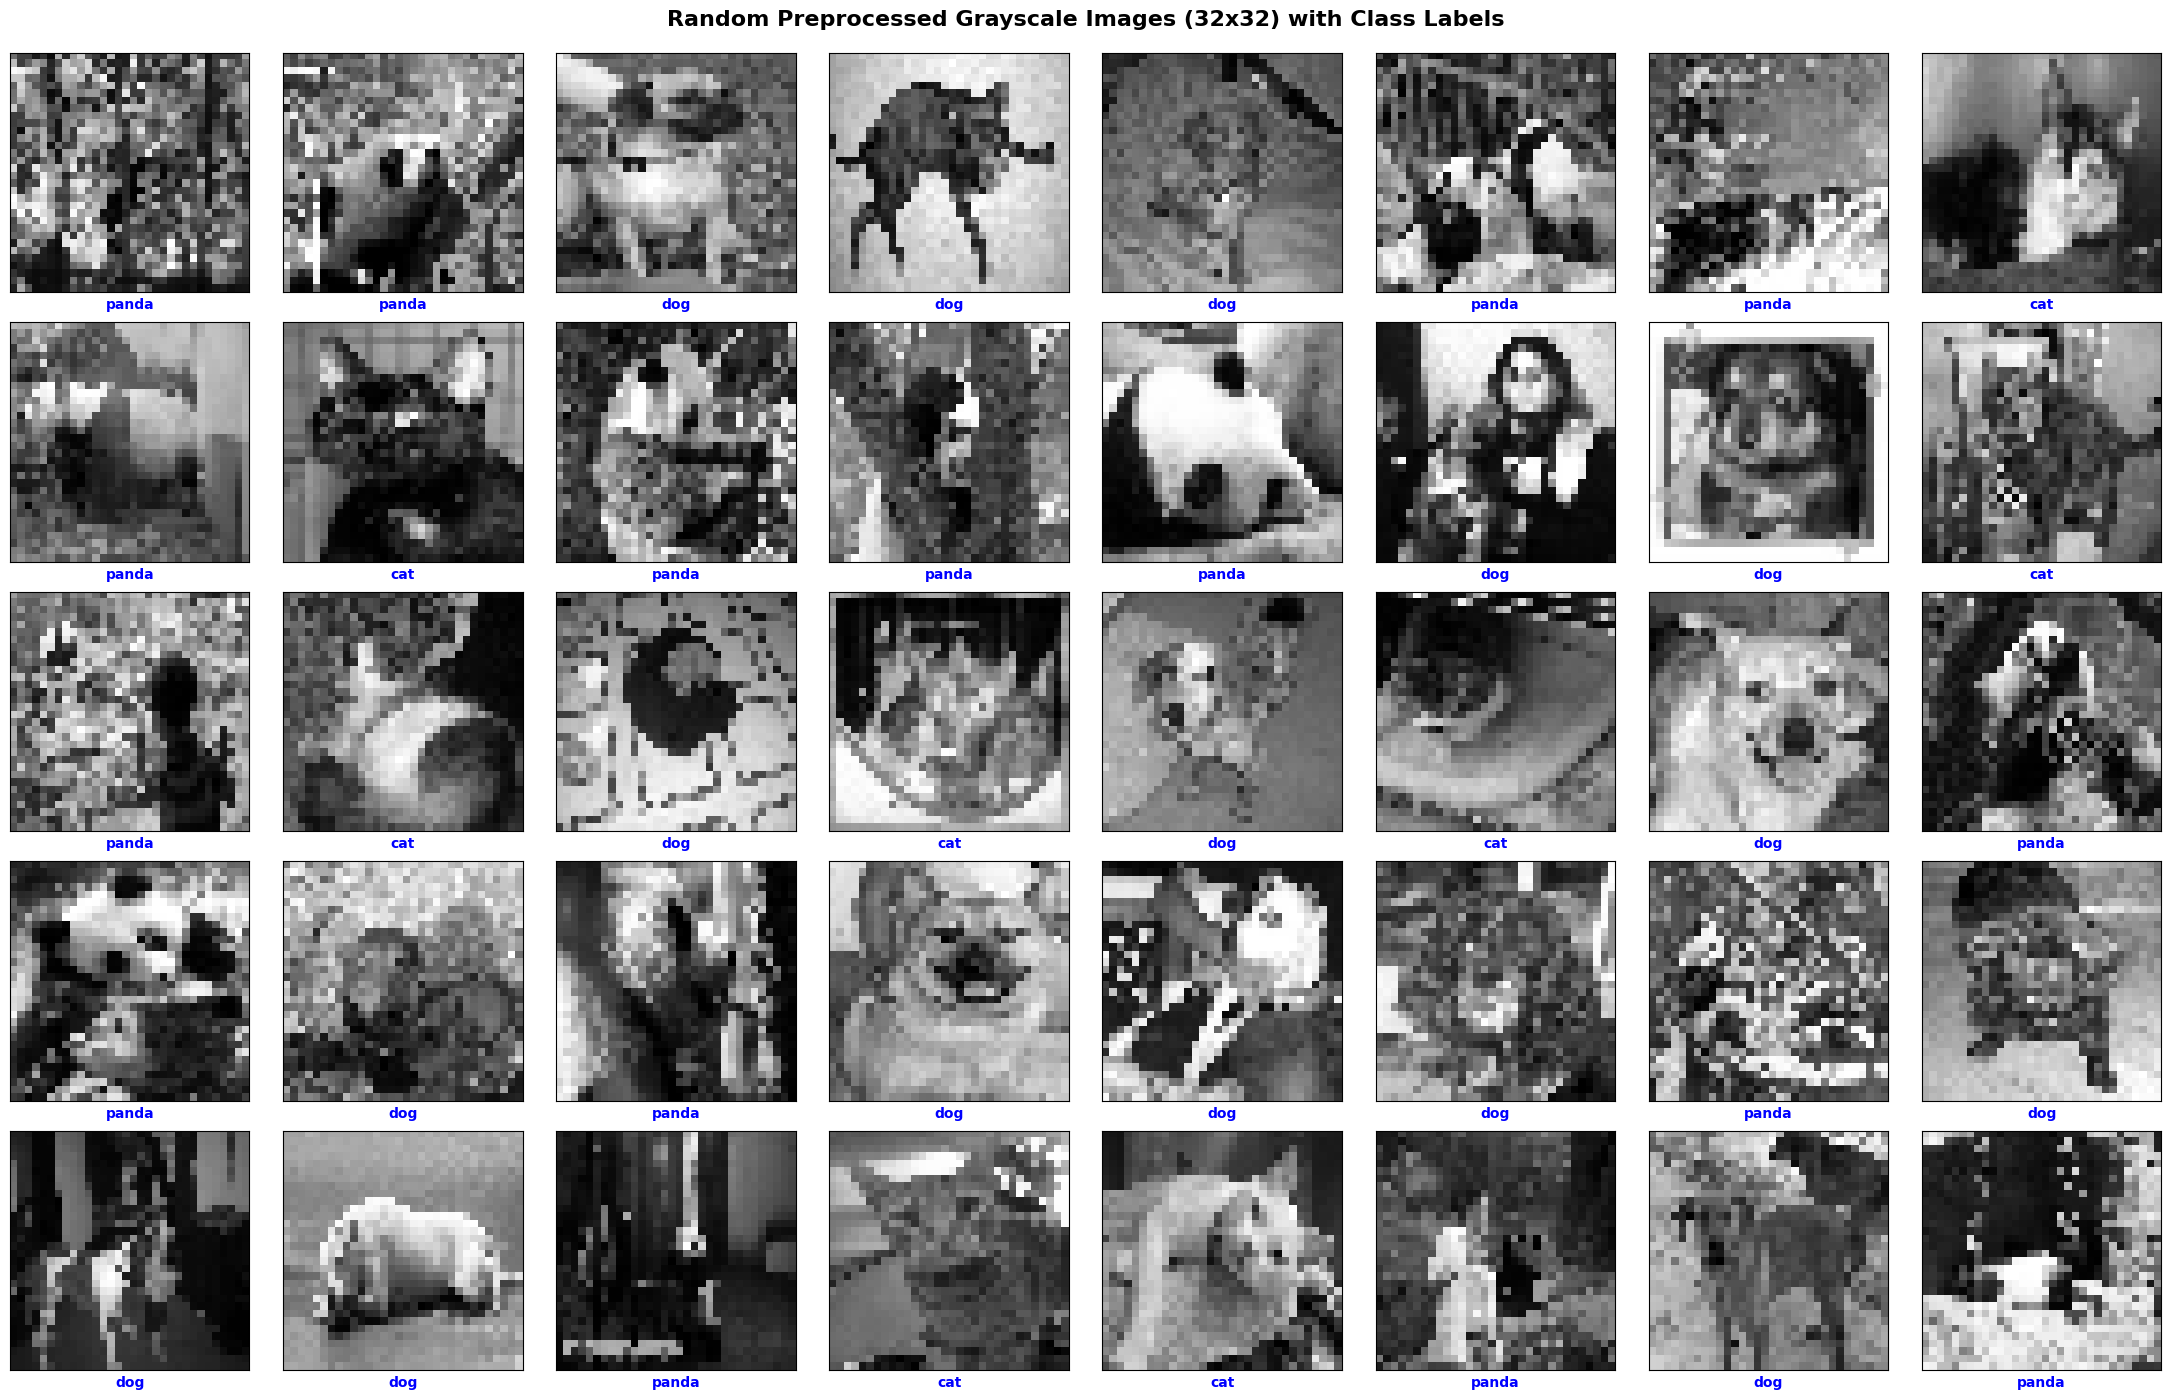

In [64]:
fig = plt.figure(figsize=(22, 14))
random_indices = random.sample(range(len(TRAIN_DATA)), 40)

for i, idx in enumerate(random_indices):
    plt.subplot(5, 8, i + 1)
    gray_img, label = TRAIN_DATA[idx]
    class_name = CATEGORIES[label]

    plt.imshow(gray_img, cmap="gray")
    plt.xlabel(class_name, fontsize=10, fontweight='bold', color='blue')
    plt.xticks([])
    plt.yticks([])

fig.suptitle("Random Preprocessed Grayscale Images (32x32) with Class Labels",
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [65]:
features = []
labels = []

for img, label in TRAIN_DATA:
    img_flat = img.flatten().astype(np.float32) / 255.0
    features.append(img_flat)
    labels.append(label)

features = np.array(features)
labels = np.array(labels)

print(f"\n Features shape: {features.shape}")
print(f" Labels shape: {labels.shape}")
print(f" Feature range: [{features.min():.3f}, {features.max():.3f}]")
print(f" Unique classes: {np.unique(labels)}")



 Features shape: (300, 1024)
 Labels shape: (300,)
 Feature range: [0.000, 1.000]
 Unique classes: [0 1 2]


In [66]:
data = list(zip(features, labels))
random.shuffle(data)

n_folds = 5
fold_size = len(data) // n_folds
folds = [data[i * fold_size : (i + 1) * fold_size] for i in range(n_folds)]

remainder = len(data) % n_folds
for i in range(remainder):
    folds[i].append(data[n_folds * fold_size + i])

print("\n✓ Fold sizes:")
for i, fold in enumerate(folds):
    print(f"   Fold {i+1}: {len(fold)} samples")



✓ Fold sizes:
   Fold 1: 60 samples
   Fold 2: 60 samples
   Fold 3: 60 samples
   Fold 4: 60 samples
   Fold 5: 60 samples


In [67]:
def manhattan_distance(vec1, vec2):
    return np.sum(np.abs(vec1 - vec2))

def euclidean_distance(vec1, vec2):
    return np.sqrt(np.sum((vec1 - vec2) ** 2))


In [68]:
def knn_predict(X_train, y_train, x_test, k=5, distance_type='l2'):
    distances = []

    for i in range(len(X_train)):
        if distance_type == 'l1':
            dist = manhattan_distance(X_train[i], x_test)
        else:
            dist = euclidean_distance(X_train[i], x_test)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])
    k_labels = [label for _, label in distances[:k]]

    # majority vote
    label_count = {}
    for label in k_labels:
        label_count[label] = label_count.get(label, 0) + 1

    most_common = max(label_count, key=label_count.get)
    return most_common


In [69]:
def run_knn_cross_validation(folds, k_values, distance_type='l2'):
    fold_wise_accuracies = []

    for fold_index in range(len(folds)):
        validation_data = folds[fold_index]
        training_data = []
        for i in range(len(folds)):
            if i != fold_index:
                training_data.extend(folds[i])

        X_train = np.array([item[0] for item in training_data])
        y_train = np.array([item[1] for item in training_data])
        X_val = np.array([item[0] for item in validation_data])
        y_val = np.array([item[1] for item in validation_data])

        fold_accuracies = []

        for k in k_values:
            correct = 0
            for i in range(len(X_val)):
                pred = knn_predict(X_train, y_train, X_val[i], k=k, distance_type=distance_type)
                if pred == y_val[i]:
                    correct += 1
            accuracy = correct / len(X_val)
            fold_accuracies.append(accuracy)

        fold_wise_accuracies.append(fold_accuracies)
        print(f" Fold {fold_index + 1}/{len(folds)} completed")

    avg_accuracies = np.mean(fold_wise_accuracies, axis=0)
    return fold_wise_accuracies, avg_accuracies


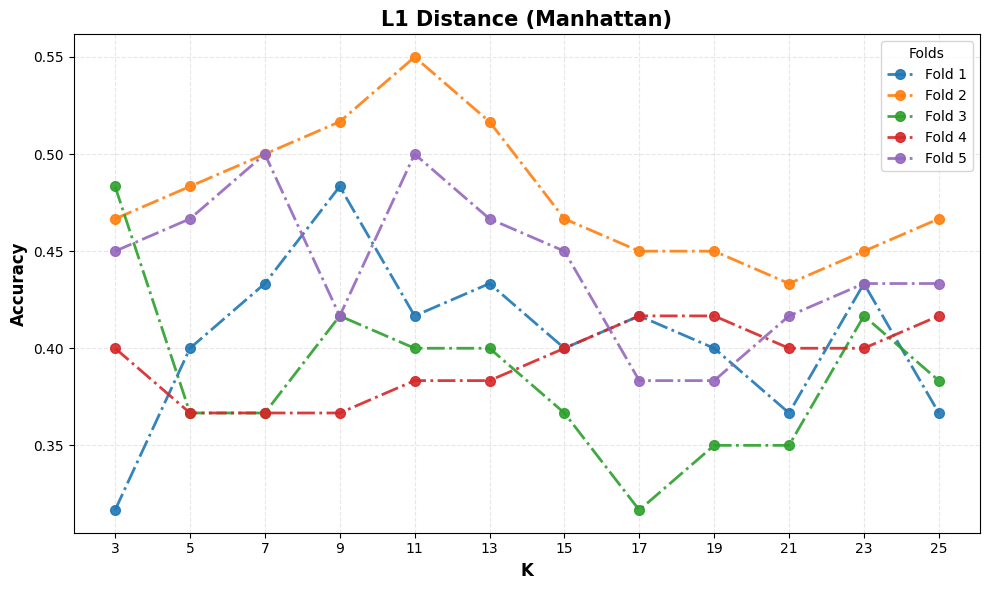

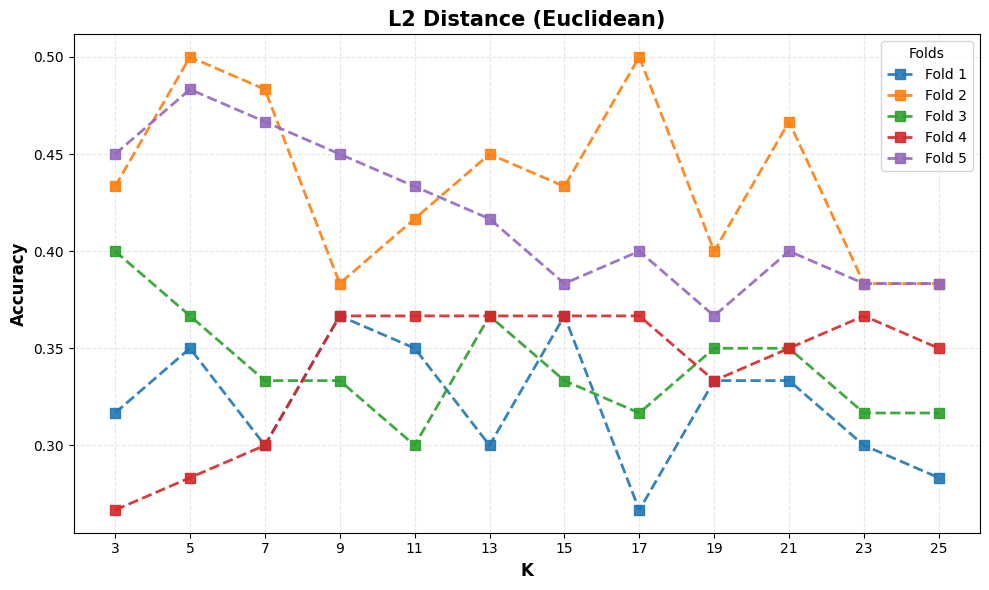

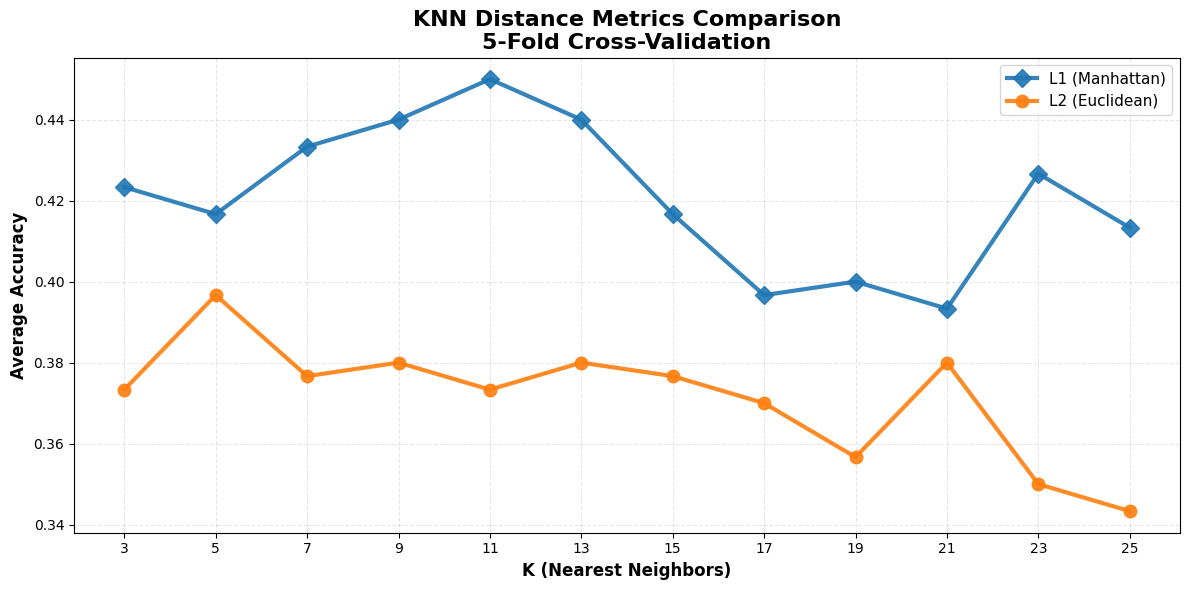

In [70]:
fold_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot L1 fold-wise
fig, ax = plt.subplots(figsize=(10, 6))
for i, acc in enumerate(fold_acc_l1):
    ax.plot(K_values, acc, marker='o', linestyle='-.', color=fold_colors[i], linewidth=2, markersize=7, label=f'Fold {i+1}', alpha=0.9)
ax.set_xlabel('K', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('L1 Distance (Manhattan)', fontsize=15, fontweight='bold')
ax.set_xticks(K_values)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(title="Folds", fontsize=10)
plt.tight_layout()
plt.show()

# Plot L2 fold-wise
fig, ax = plt.subplots(figsize=(10, 6))
for i, acc in enumerate(fold_acc_l2):
    ax.plot(K_values, acc, marker='s', linestyle='--', color=fold_colors[i], linewidth=2, markersize=7, label=f'Fold {i+1}', alpha=0.9)
ax.set_xlabel('K', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('L2 Distance (Euclidean)', fontsize=15, fontweight='bold')
ax.set_xticks(K_values)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(title="Folds", fontsize=10)
plt.tight_layout()
plt.show()

# Plot average comparison
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(K_values, avg_acc_l1, marker='D', linestyle='-', linewidth=3, markersize=9, label='L1 (Manhattan)', alpha=0.9)
ax.plot(K_values, avg_acc_l2, marker='o', linestyle='-', linewidth=3, markersize=9, label='L2 (Euclidean)', alpha=0.9)
ax.set_xlabel('K (Nearest Neighbors)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Accuracy', fontsize=12, fontweight='bold')
ax.set_title('KNN Distance Metrics Comparison\n5-Fold Cross-Validation', fontsize=16, fontweight='bold')
ax.set_xticks(K_values)
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()



Using: L1 distance with K=11


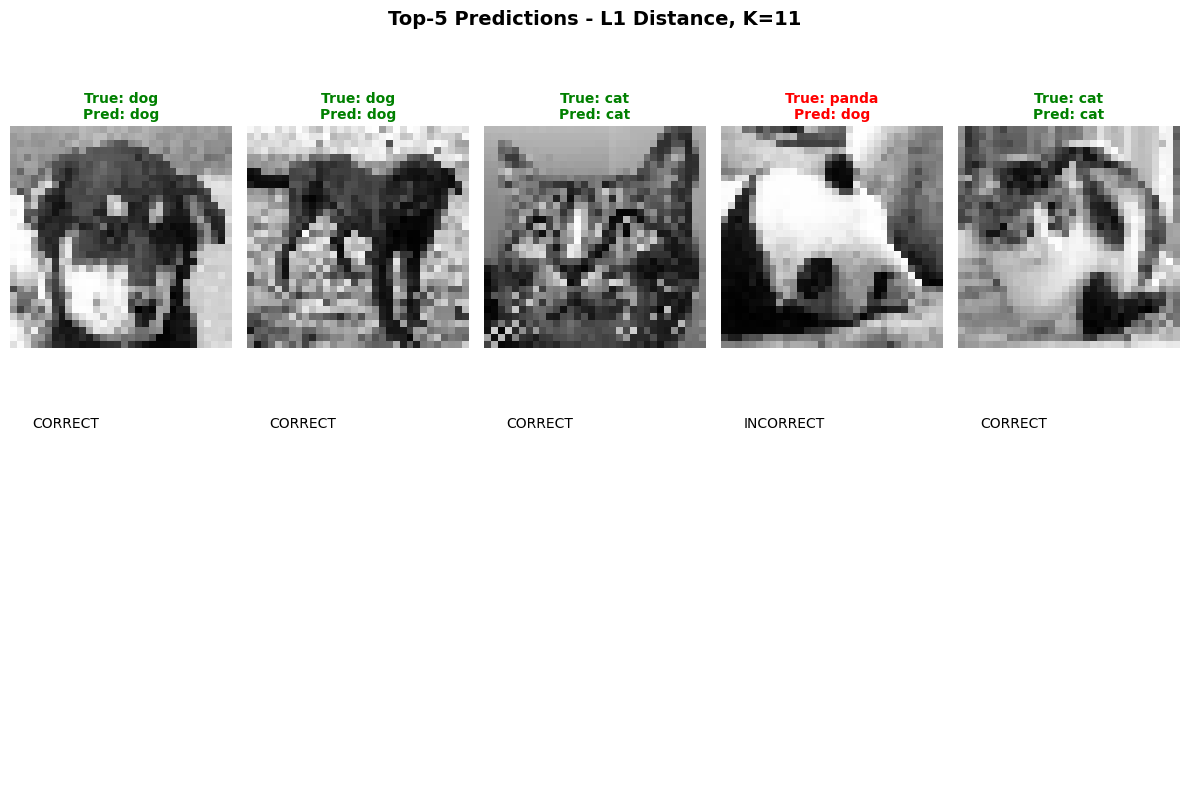

Correct: 4/5
Accuracy: 80.00%


In [71]:
# choose best config from CV
best_metric = 'l2' if best_acc_l2 > best_acc_l1 else 'l1'
best_k = best_k_l2 if best_acc_l2 > best_acc_l1 else best_k_l1

print(f"\nUsing: {best_metric.upper()} distance with K={best_k}")

# create train/test from folds (use fold 0 as test)
test_data = folds[0]
train_data = []
for i in range(1, len(folds)):
    train_data.extend(folds[i])

X_train = np.array([item[0] for item in train_data])
y_train = np.array([item[1] for item in train_data])

num_test = 5
fig, axes = plt.subplots(2, num_test, figsize=(12, 8))
correct_count = 0

for idx in range(num_test):
    x_test, y_true = test_data[idx]
    y_pred = knn_predict(X_train, y_train, x_test, k=best_k, distance_type=best_metric)
    is_correct = (y_pred == y_true)
    if is_correct:
        correct_count += 1

    ax_img = axes[0, idx]
    img_display = x_test.reshape(IMG_SIZE, IMG_SIZE)
    ax_img.imshow(img_display, cmap='gray')
    ax_img.axis('off')

    border_color = 'green' if is_correct else 'red'
    for spine in ax_img.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    title = f"True: {CATEGORIES[y_true]}\nPred: {CATEGORIES[y_pred]}"
    ax_img.set_title(title, fontsize=10, fontweight='bold', color=border_color)

    ax_text = axes[1, idx]
    ax_text.axis('off')
    info_text = f"{'CORRECT' if is_correct else 'INCORRECT'}"
    ax_text.text(0.1, 0.9, info_text)

fig.suptitle(f'Top-5 Predictions - {best_metric.upper()} Distance, K={best_k}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Correct: {correct_count}/{num_test}")
print(f"Accuracy: {correct_count/num_test*100:.2f}%")


In [72]:
#Comparison Between Manhattan (L1) and Euclidean (L2)

print("\n KNN DISTANCE METRIC COMPARISON ")

print(f"{'K':<5}{'L1 Accuracy (%)':<20}{'L2 Accuracy (%)'}")
print("-" * 45)

for k, acc1, acc2 in zip(K_values, avg_acc_l1, avg_acc_l2):
    print(f"{k:<5}{acc1*100:<20.2f}{acc2*100:.2f}")

print("\n BEST PERFORMANCE ")

print(f"Best L1 Accuracy : {best_acc_l1*100:.2f}% at K = {best_k_l1}")
print(f"Best L2 Accuracy : {best_acc_l2*100:.2f}% at K = {best_k_l2}")

winner = "Manhattan (L1)" if best_acc_l1 > best_acc_l2 else "Euclidean (L2)"
difference = abs(best_acc_l1 - best_acc_l2) * 100

print("\nWinner Metric     :", winner)
print("Accuracy Gap      : {:.2f}%".format(difference))
print("\n")




 KNN DISTANCE METRIC COMPARISON 
K    L1 Accuracy (%)     L2 Accuracy (%)
---------------------------------------------
3    42.33               37.33
5    41.67               39.67
7    43.33               37.67
9    44.00               38.00
11   45.00               37.33
13   44.00               38.00
15   41.67               37.67
17   39.67               37.00
19   40.00               35.67
21   39.33               38.00
23   42.67               35.00
25   41.33               34.33

 BEST PERFORMANCE 
Best L1 Accuracy : 45.00% at K = 11
Best L2 Accuracy : 39.67% at K = 5

Winner Metric     : Manhattan (L1)
Accuracy Gap      : 5.33%




### KNN Distance Metric Comparison Discussion

- The Manhattan distance (L1) produced consistently higher accuracy values than the Euclidean distance (L2) for nearly all values of K, indicating that L1 aligns better with the characteristics of this dataset.
- The highest L1 accuracy was **45% at K = 11**, while the best L2 accuracy reached **39.67% at K = 5**, resulting in a performance gap of **5.33%** in favor of L1.
- L2 accuracy fluctuated more across different K values, suggesting greater sensitivity to noise and pixel-level variations in the grayscale images.
- L1 often performs better in **high-dimensional or noisy feature spaces**, and since each 32×32 grayscale image becomes a 1024-dimensional vector, L1 handles the feature space more robustly.
- The relatively small dataset size (300 training images) also contributes to L2 instability, as Euclidean distance tends to be more affected by sharp pixel differences even between similar images.

### Limitations

- The overall accuracy remains modest because k-NN does not extract meaningful features from raw pixel representations; using feature extraction methods (HOG, PCA) or deep learning embeddings could significantly improve accuracy.
- The dataset size is small, which limits the generalization performance of distance-based classifiers.
- Only grayscale 32×32 resized images were used; different preprocessing choices might influence the relative performance of L1 and L2.
- Only k-NN was evaluated; other classifiers such as SVM, Random Forest, or lightweight CNNs may outperform k-NN for this type of image dataset.

### Conclusion

Based on the 5-fold cross-validation results and considering the dataset’s dimensionality and size, **Manhattan (L1) distance demonstrates better performance** and is more suitable for this image classification task compared to the Euclidean (L2) distance.
